In [1]:
import pandas as pd
import matplotlib.pyplot as plt
pings = pd.read_csv('ping_series_20260611_113258.csv')

In [7]:
pings_by_target = pings.groupby('target_hostname')

In [8]:
pings_by_target.describe()

probe_id                                                 \
                   count           mean            std     min      25%   
target_hostname                                                           
dunyanews.tv       683.0  432199.320644  477013.272053  7613.0  60223.0   
hbl.com            684.0  431578.580409  476940.320394  7613.0  60223.0   
mcb.com.pk         683.0  432199.320644  477013.272053  7613.0  60223.0   
pseb.org.pk        685.0  430959.652555  476866.765271  7613.0  60223.0   
ptcl.com.pk        685.0  430959.652555  476866.765271  7613.0  60223.0   

                                               probe_asn                ...  \
                     50%        75%        max     count          mean  ...   
target_hostname                                                         ...   
dunyanews.tv     62224.0  1015679.0  1016036.0     683.0  71822.169839  ...   
hbl.com          62224.0  1015679.0  1016036.0     684.0  71940.273392  ...   
mcb.com.pk       62224.0  1015679.0  1016036.0     683.0  71822.169839  ...   
pseb.org.pk      62224.0  1015679.0  1016036.0     685.0  72058.032117  ...   
ptcl.com.pk      62224.0  1015679.0  1016036.0     685.0  72058.032117  ...   

                    rtt_max              measurement_id                    \
                        75%          max          count         mean  std   
target_hostname                                                             
dunyanews.tv      42.562990   102.634742          683.0  179311285.0  0.0   
hbl.com          211.978411  2796.938444          684.0  179311292.0  0.0   
mcb.com.pk       140.378698   199.207219          683.0  179311301.0  0.0   
pseb.org.pk       42.122007  4098.615493          685.0  179311311.0  0.0   
ptcl.com.pk             NaN          NaN          685.0  179311307.0  0.0   

                                                                     \
                         min          25%          50%          75%   
target_hostname                                                       
dunyanews.tv     179311285.0  179311285.0  179311285.0  179311285.0   
hbl.com          179311292.0  179311292.0  179311292.0  179311292.0   
mcb.com.pk       179311301.0  179311301.0  179311301.0  179311301.0   
pseb.org.pk      179311311.0  179311311.0  179311311.0  179311311.0   
ptcl.com.pk      179311307.0  179311307.0  179311307.0  179311307.0   

                              
                         max  
target_hostname               
dunyanews.tv     179311285.0  
hbl.com          179311292.0  
mcb.com.pk       179311301.0  
pseb.org.pk      179311311.0  
ptcl.com.pk      179311307.0  

[5 rows x 72 columns]

In [32]:
timed_pings_by_target = pings_by_target[['target_hostname','ping_time', 'probe_id','rtt_max']]

In [33]:
single_host_df = timed_pings_by_target.get_group('dunyanews.tv')

Text(0.5, 1.0, 'Dunya News')

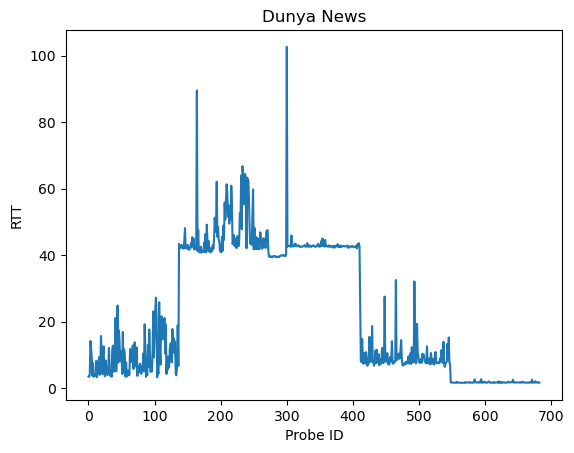

In [28]:
fig, ax = plt.subplots()
ax.plot(single_host_df['rtt_max'])
ax.set_xlabel('Probe ID')
ax.set_ylabel('RTT')
ax.set_title('Dunya News')

In [29]:
single_host_df['rtt_max']

0       3.516615
1       3.378691
2       4.210383
3      14.204034
4      11.894345
         ...    
678     1.711459
679     1.722645
680     1.663974
681     1.774869
682     1.674428
Name: rtt_max, Length: 683, dtype: float64

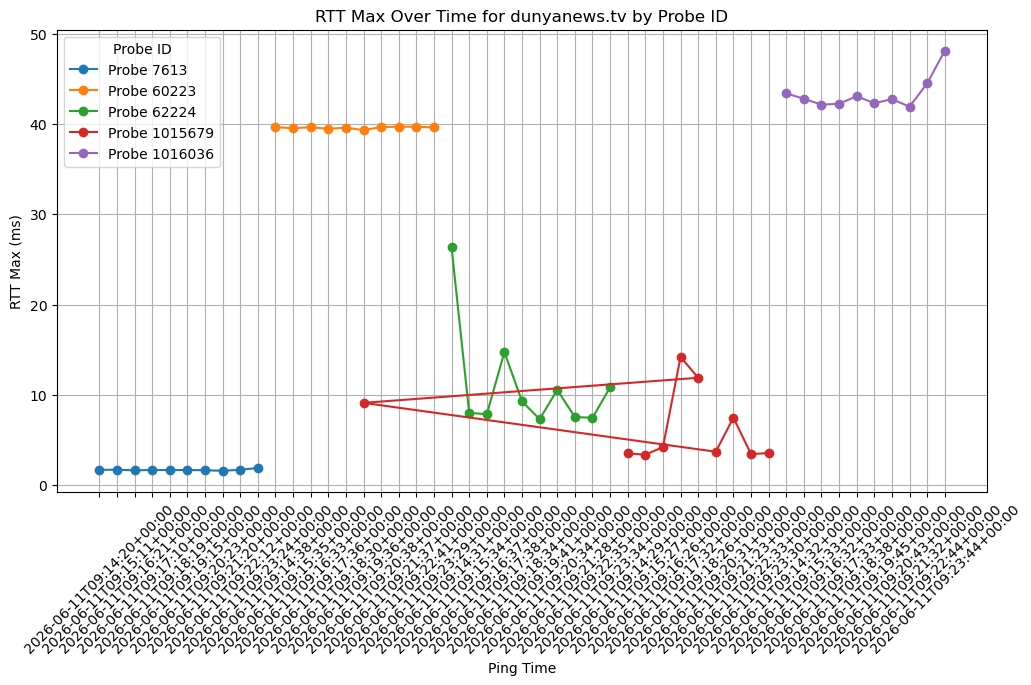

In [37]:
plt.figure(figsize=(12, 6))

single_host_df = single_host_df.sort_values('ping_time')

# 2. Grab the first 20 rows FOR EACH probe_id
per_probe_first_20 = single_host_df.groupby('probe_id').head(10)

# 3. Now loop through our new subsetted dataframe to plot
for probe_id, group in per_probe_first_20.groupby('probe_id'):
    plt.plot(
        group['ping_time'], 
        group['rtt_max'], 
        label=f'Probe {probe_id}', 
        marker='o'
    )

plt.title('RTT Max Over Time for dunyanews.tv by Probe ID')
plt.xlabel('Ping Time')
plt.ylabel('RTT Max (ms)')
plt.xticks(rotation=45)
plt.legend(title='Probe ID')
plt.grid(True)

plt.show()

In [48]:
srt = per_probe_first_20.sort_values(['probe_id', 'ping_time'])
srt.iloc[:, 1:]

,ping_time,probe_id,rtt_max
548,2026-06-11T09:14:20+00:00,7613,1.694596
549,2026-06-11T09:15:11+00:00,7613,1.719003
550,2026-06-11T09:16:21+00:00,7613,1.638613
551,2026-06-11T09:17:10+00:00,7613,1.687900
552,2026-06-11T09:18:19+00:00,7613,1.671866
553,2026-06-11T09:19:15+00:00,7613,1.676101
554,2026-06-11T09:20:23+00:00,7613,1.655352
555,2026-06-11T09:21:20+00:00,7613,1.598717
556,2026-06-11T09:22:12+00:00,7613,1.705555
557,2026-06-11T09:23:24+00:00,7613,1.905082


In [53]:
per_probe_first_20['ping_time'] = pd.to_datetime(per_probe_first_20['ping_time'])
srt = per_probe_first_20.sort_values(['ping_time'])

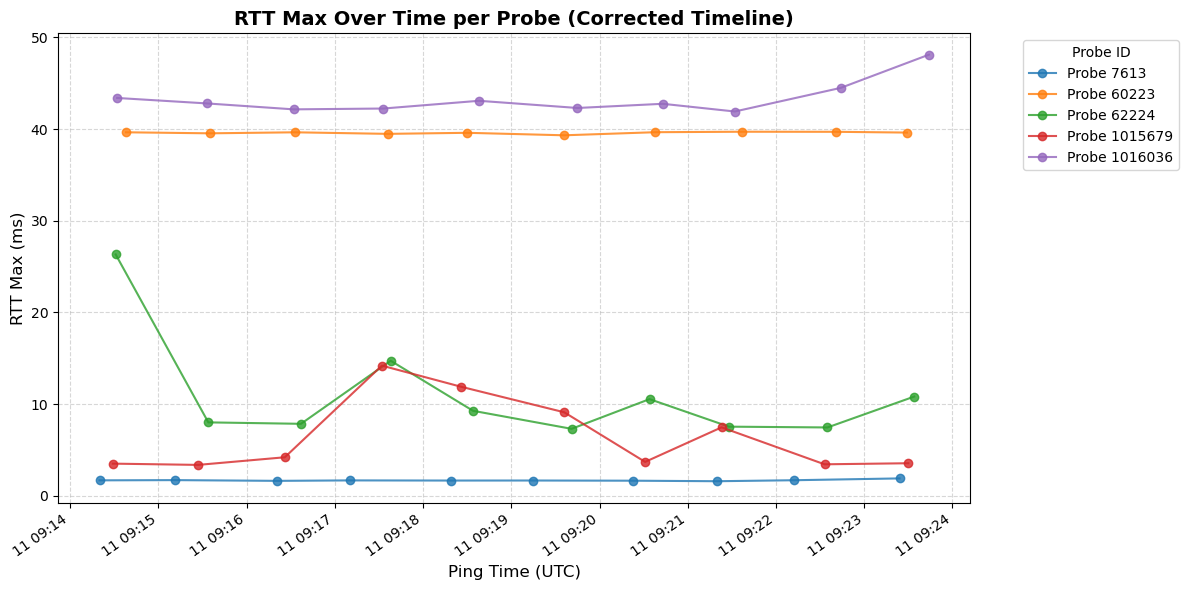

In [52]:
per_probe = per_probe_first_20.sort_values('ping_time')

# 3. Plot
plt.figure(figsize=(12, 6))

for probe_id, group in per_probe_first_20.groupby('probe_id'):
    plt.plot(
        group['ping_time'], 
        group['rtt_max'], 
        label=f'Probe {probe_id}', 
        marker='o',
        alpha=0.8 # Makes lines slightly transparent so overlapping lines are visible
    )

plt.title('RTT Max Over Time per Probe (Dunya News)', fontsize=14, fontweight='bold')
plt.xlabel('Ping Time (UTC)', fontsize=12)
plt.ylabel('RTT Max (ms)', fontsize=12)

plt.xticks(rotation=35, ha='right')
plt.legend(title='Probe ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

In [54]:
single_host_df['ping_time'] = pd.to_datetime(single_host_df['ping_time'])
srt = single_host_df.sort_values(['ping_time'])

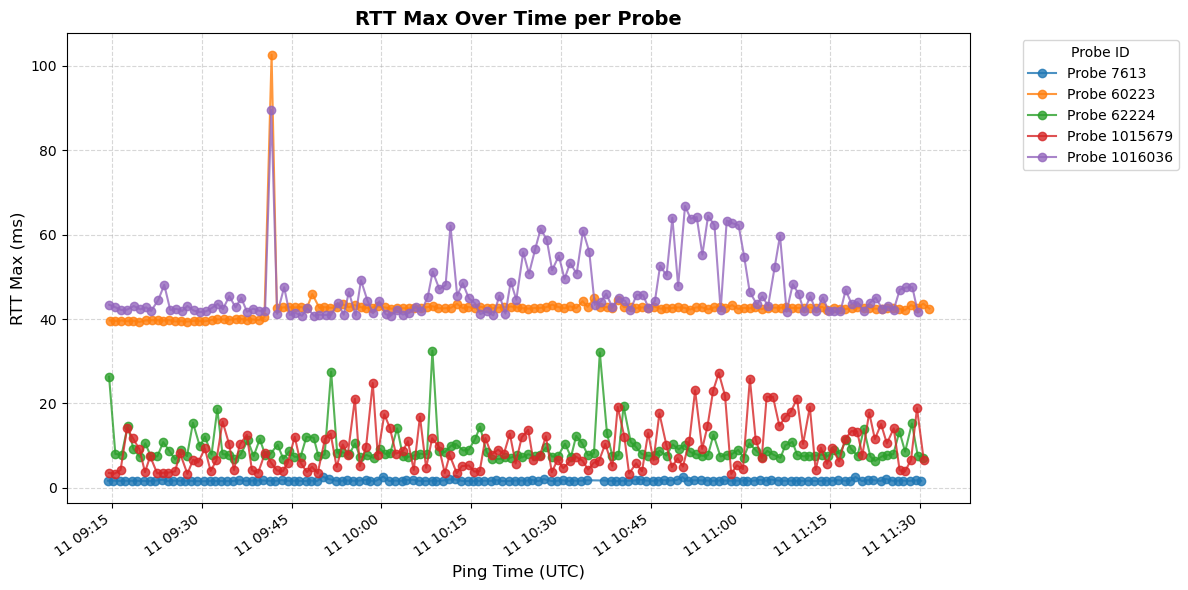

In [56]:
def plot(df):
    per_probe = df.sort_values('ping_time')

    # 3. Plot
    plt.figure(figsize=(12, 6))
    
    for probe_id, group in df.groupby('probe_id'):
        plt.plot(
            group['ping_time'], 
            group['rtt_max'], 
            label=f'Probe {probe_id}', 
            marker='o',
            alpha=0.8 # Makes lines slightly transparent so overlapping lines are visible
        )
    
    plt.title('RTT Max Over Time per Probe', fontsize=14, fontweight='bold')
    plt.xlabel('Ping Time (UTC)', fontsize=12)
    plt.ylabel('RTT Max (ms)', fontsize=12)
    
    plt.xticks(rotation=35, ha='right')
    plt.legend(title='Probe ID', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
plot(single_host_df)